In [1]:
from models.post_proj_res_conv import post_proj_res_conv
from models.PP3DR import PP3DR
# from models.PP3DR_DPT import PP3DR_DPT
import torch
from datasets.nrgbd_dataset import nrgbd_dataset
from datasets.dtu_dataset import dtu_dataset
from datasets.dynamic_replica_dataset import dynamic_replica_dataset
from datasets.eth3d_dataset import eth3d_dataset
from datasets.flying_things_3d_dataset import flying_things_3d_dataset
from datasets.sintel_dataset import sintel_dataset
import matplotlib.pyplot as plt

/vulcanscratch/hughma/miniconda3/envs/Pi3/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# model = post_proj_res_conv()
model = PP3DR()
remove_front = False
# I want to see which parameters are left over after loading this.
loaded_state_dict = torch.load("/vulcanscratch/hughma/PP3DR/LDD-Dn-1000-finetune/PP3DR.pth", weights_only=True)
if remove_front:
    # The lines here are necessary if all the loaded state dict entries begin with an extra "module."
    new_state_dict = {}
    for key in loaded_state_dict:
        new_state_dict[key[7:]] = loaded_state_dict[key]
    model.load_state_dict(new_state_dict)
else:
    model.load_state_dict(loaded_state_dict)
print("post load")

model = model.eval().to("cuda")
dataset = nrgbd_dataset()
# dataset = sintel_dataset()

post load


Precomputing NRGBD image file paths: 9it [00:00, 211.20it/s]


post dataset


/vulcanscratch/hughma/miniconda3/envs/Pi3/lib/python3.14/site-packages/torch/_dynamo/utils.py:3694: UserWarning: Mismatch dtype between input and weight: input dtype = c10::BFloat16, weight dtype = float, Cannot dispatch to fused implementation. (Triggered internally at /home/task_177771236509760/croot/libtorch_1777712413063/work/aten/src/ATen/native/layer_norm.cpp:344.)
  return node.target(*args, **kwargs)  # type: ignore[operator]


post pred
log_depths: (1, 10, 512, 512)
fx: (1, 10)
fy: (1, 10)
cx: (1, 10)
cy: (1, 10)
relative_camera_translations: (1, 9, 3)
relative_camera_rotations: (1, 9, 3, 3)
done
2.3223495


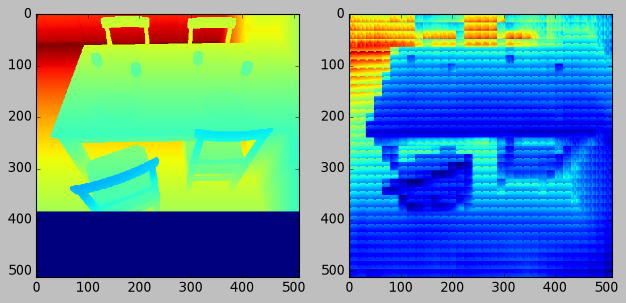

In [3]:
data = dataset[4] # 8
print("post dataset")
for key in data:
    data[key] = data[key].unsqueeze(0)
with torch.amp.autocast("cuda", dtype = torch.bfloat16), torch.no_grad():
    pred = model(data['images'].to("cuda"), data['rope_x'].to("cuda"), data['rope_y'].to("cuda"))
print("post pred")
for key in pred:
    pred[key] = pred[key].to(torch.float32).cpu().numpy(force=True)
    print(f"{key}: {pred[key].shape}")
print("done")
import numpy as np
# plt.style.use("seaborn-v0_8-darkgrid")
plt.style.use("classic")
fig, (a1, a2) = plt.subplots(1, 2)
a1.imshow(data['depths'][0][0])
a2.imshow(np.exp(pred['log_depths'][0][0]))
print(pred['log_depths'][0][0].mean())
fig.tight_layout()